# Question 22: Is there a relationship between a player's average number of aces per match and their win rate?

Using `statistics`, `home_team`, `away_team`, `event`

In [35]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [36]:
MINI_PROJECT_ROOT = Path.cwd().parents[2]

DATA_ROOT = (
    MINI_PROJECT_ROOT
    / "Tennis Schema"
    / "tennis_data"
)

PROCESSED_ROOT = DATA_ROOT / "processed"

TEAM_DATA_ROOT = DATA_ROOT / "Data"

In [37]:
statistics = pd.read_parquet(PROCESSED_ROOT / "statistics_clean.parquet")
home_team = pd.read_parquet(TEAM_DATA_ROOT / "home_team.parquet")
away_team = pd.read_parquet(TEAM_DATA_ROOT / "away_team.parquet")
match_event = pd.read_parquet(TEAM_DATA_ROOT / "event.parquet")

print("Statistics columns:")
print(statistics.columns.tolist())

print("\nHome columns:")
print(home_team.columns.tolist())

print("\nAway columns:")
print(away_team.columns.tolist())

print("\nEvent columns:")
print(match_event.columns.tolist())

Statistics columns:
['match_id', 'period', 'statistic_category_name', 'statistic_name', 'home_stat', 'away_stat', 'compare_code', 'statistic_type', 'value_type', 'home_value', 'away_value', 'home_total', 'away_total', 'snapshot_date', 'invalid_team_stat']

Home columns:
['match_id', 'name', 'slug', 'gender', 'user_count', 'residence', 'birthplace', 'height', 'weight', 'plays', 'turned_pro', 'current_prize', 'total_prize', 'player_id', 'current_rank', 'name_code', 'country', 'full_name', 'snapshot_date']

Away columns:
['match_id', 'name', 'slug', 'gender', 'user_count', 'residence', 'birthplace', 'height', 'weight', 'plays', 'turned_pro', 'current_prize', 'total_prize', 'player_id', 'current_rank', 'name_code', 'country', 'full_name', 'snapshot_date']

Event columns:
['match_id', 'first_to_serve', 'home_team_seed', 'away_team_seed', 'custom_id', 'winner_code', 'default_period_count', 'start_datetime', 'match_slug', 'final_result_only', 'snapshot_date', 'match_datetime']


In [38]:
# Inspect how ace statistics are stored

aces_check = statistics[statistics["statistic_name"].str.contains("ace", case=False, na=False)]

aces_check[["period", "statistic_category_name", "statistic_name", "value_type"]
           ].drop_duplicates().sort_values(["statistic_name", "period"]).reset_index(drop=True)

,period,statistic_category_name,statistic_name,value_type
0,1ST,service,aces,event
1,2ND,service,aces,event
2,3RD,service,aces,event
3,ALL,service,aces,event


In [39]:
# Keep total ace statistics for each match

aces_all = statistics[(statistics["statistic_name"] == "aces") & (statistics["period"] == "ALL")].copy()

aces_all[["match_id", "home_value", "away_value", "snapshot_date"]].head()


,match_id,home_value,away_value,snapshot_date
0,11998445,12.0,6.0,2024-02-01
71,11998446,6.0,3.0,2024-02-01
125,11998447,8.0,4.0,2024-02-01
178,11998448,4.0,0.0,2024-02-01
232,11998449,6.0,4.0,2024-02-01


In [40]:
# Keep the latest record for each match

aces_final = (aces_all.sort_values(["match_id", "snapshot_date"]).drop_duplicates(subset="match_id", keep="last"))

home_final = (home_team.sort_values(["match_id", "snapshot_date"]).drop_duplicates(subset="match_id", keep="last"))

away_final = (away_team.sort_values(["match_id", "snapshot_date"]).drop_duplicates(subset="match_id", keep="last"))

event_final = (match_event.sort_values(["match_id", "snapshot_date"]).drop_duplicates(subset="match_id", keep="last"))

print("Ace matches:", len(aces_final))
print("Home matches:", len(home_final))
print("Away matches:", len(away_final))
print("Event matches:", len(event_final))

Ace matches: 11389
Home matches: 12389
Away matches: 11690
Event matches: 16873


In [41]:
# Combine ace totals with player identities and match winners

matches_aces = (aces_final[["match_id", "home_value", "away_value"]]
    .merge(home_final[["match_id", "player_id", "full_name"]]
        .rename(columns={"player_id": "home_player_id", "full_name": "home_player"}), on="match_id", how="inner")

    .merge(away_final[["match_id", "player_id", "full_name"]]
        .rename(columns={"player_id": "away_player_id", "full_name": "away_player"}), on="match_id", how="inner")
    .merge(event_final[["match_id", "winner_code"]], on="match_id", how="inner"))

print("Matches available for analysis:", len(matches_aces))

matches_aces[["match_id", "home_player", "home_value", "away_player", "away_value", "winner_code"]].head()

Matches available for analysis: 8987


,match_id,home_player,home_value,away_player,away_value,winner_code
0,11998445,"Cazaux, Arthur",12.0,"Auger-Aliassime, Felix",6.0,2.0
1,11998446,"Lestienne, Constant",6.0,Flavio Cobolli,3.0,2.0
2,11998447,"Ćorić, Borna",8.0,"Martinez, Pedro",4.0,1.0
3,11998448,"Mmoh, Michael",4.0,"Muller, Alexandre",0.0,1.0
4,11998449,"Paire, Benoit",6.0,"Mayot, Harold",4.0,2.0


In [42]:
# Create one record per player and match

home_players = matches_aces[["home_player_id", "home_player", "home_value", "winner_code"]].copy()

home_players = home_players.rename(columns={"home_player_id": "player_id", "home_player": "player", "home_value": "aces"})

home_players["won"] = home_players["winner_code"] == 1


away_players = matches_aces[["away_player_id", "away_player", "away_value", "winner_code"]].copy()

away_players = away_players.rename(columns={"away_player_id": "player_id", "away_player": "player", "away_value": "aces"})

away_players["won"] = away_players["winner_code"] == 2


player_matches = pd.concat([home_players, away_players], ignore_index=True)

print(" All player-match records:", len(player_matches))

player_matches[["player_id", "player", "aces", "won"]].sort_values("aces", ascending=True).head() #making sure the matched with 0 ace are also included

 All player-match records: 17974


,player_id,player,aces,won
17959,255418,"Justo, Guido Ivan",0.0,False
17958,217449,"Gimeno Valero, Carlos",0.0,True
17969,60650,"Bonardi, Berta",0.0,True
4783,341818,"Faria, Jaime",0.0,True
4782,230049,"Jianu, Filip Cristian",0.0,True


In [43]:
# Keep player-match records with valid winners and ace values

player_matches_valid = player_matches[player_matches["winner_code"].isin([1, 2]) & player_matches["aces"].notna()].copy()

print("Player-match records available for analysis:", len(player_matches_valid))

player_matches_valid[["player_id", "player", "aces", "won"]].sort_values("aces", ascending=True).head()

Player-match records available for analysis: 17954


,player_id,player,aces,won
4771,137932,"Mikulskytė, Justina",0.0,True
4770,152074,"Rioux, Lisa-Marie",0.0,False
4767,194579,"Yuan, Chengyiyi",0.0,False
4766,190950,"Ma, Yexin",0.0,False
4764,420632,"Jovic, Iva",0.0,True


In [44]:
# Calculate each player's average aces and win rate

player_stats = (player_matches_valid.groupby(["player_id", "player"])
    .agg( matches=("won", "size"), wins=("won", "sum"), average_aces=("aces", "mean")).reset_index())

player_stats["win_rate"] = (player_stats["wins"] / player_stats["matches"] * 100)

player_stats.sort_values("matches", ascending=False).head()

,player_id,player,matches,wins,average_aces,win_rate
212,50901,"Popko, Dmitry",31,27,3.967742,87.096774
1927,338890,"Merida Aguilar, Daniel",26,18,1.730769,69.230769
1319,231620,"Chidekh, Clement",25,23,1.880000,92.000000
84,26204,"Basilashvili, Nikoloz",24,15,3.666667,62.500000
1761,302567,"Sakellaridis, Stefanos",24,17,8.791667,70.833333


In [45]:
# Keep players with at least 3 matches

player_stats_filtered = player_stats[player_stats["matches"] >= 3].copy()

print("Players before filtering:", len(player_stats))
print("Players after filtering:", len(player_stats_filtered))

player_stats_filtered.sort_values("matches", ascending=False).head()

Players before filtering: 2441
Players after filtering: 1978


,player_id,player,matches,wins,average_aces,win_rate
212,50901,"Popko, Dmitry",31,27,3.967742,87.096774
1927,338890,"Merida Aguilar, Daniel",26,18,1.730769,69.230769
1319,231620,"Chidekh, Clement",25,23,1.880000,92.000000
1761,302567,"Sakellaridis, Stefanos",24,17,8.791667,70.833333
84,26204,"Basilashvili, Nikoloz",24,15,3.666667,62.500000


In [46]:
# Calculate the correlation between average aces and win rate

correlation = player_stats_filtered["average_aces"].corr(player_stats_filtered["win_rate"])

print(f"Correlation: {correlation:.3f}")

Correlation: 0.163


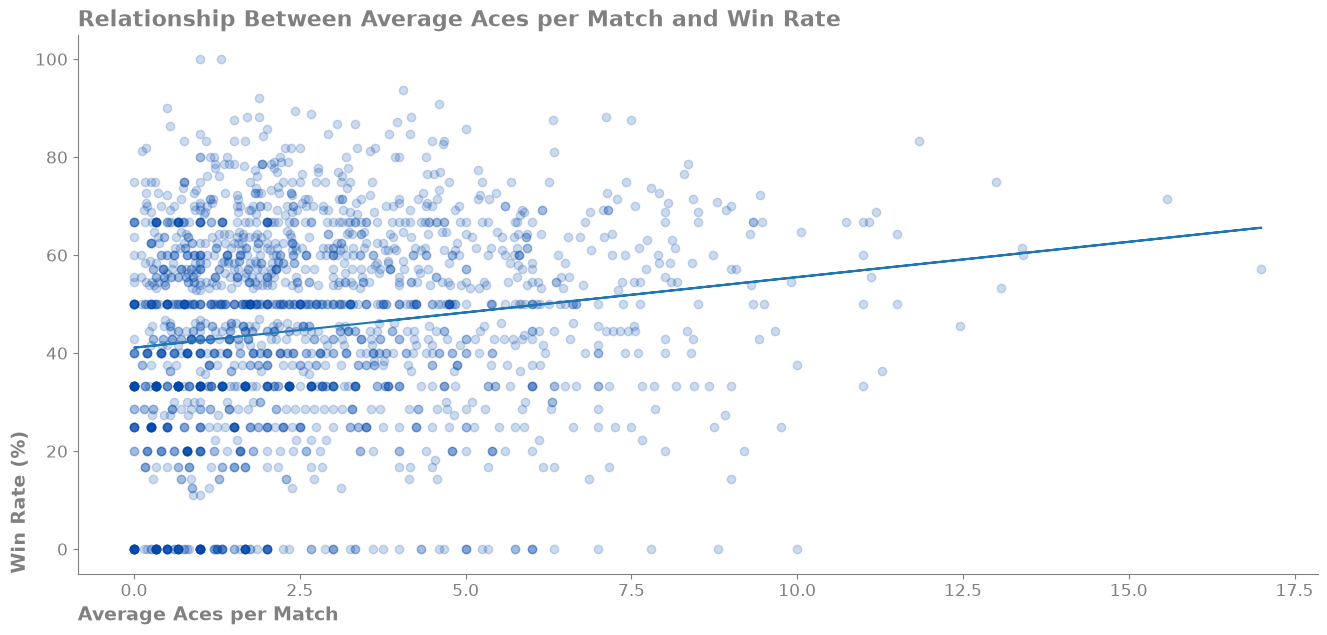

In [47]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.scatter(
    x=player_stats_filtered["average_aces"],
    y=player_stats_filtered["win_rate"],
    alpha=.2,
    color='#0047AB')

ax.spines[["right", "top"]].set_visible(False)

ax.spines[["left", "bottom"]].set_color("gray")

ax.set_title(
    "Relationship Between Average Aces per Match and Win Rate",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=16,)

ax.set_xlabel(
    "Average Aces per Match",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=14)

ax.set_ylabel(
    "Win Rate (%)",
    loc="bottom",
    weight="bold",
    color="gray",
    fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large")

ax.tick_params(axis="y", colors="gray", labelsize="large")

m, b = np.polyfit(player_stats_filtered["average_aces"], player_stats_filtered["win_rate"], 1)

ax.plot(player_stats_filtered["average_aces"], m * player_stats_filtered["average_aces"] + b)

plt.show()

The relationship between the two variables is positive but not meaningfull. 